# T13 Anomaly — GLARE Score Analysis

Examines why T13_extra mislabeled samples are not detected by GLARE (most have score 8 instead of 0).  
Visualises patches side-by-side sorted by GLARE score so we can see if the images look anatomically similar to their Lumbar neighbours.

In [1]:
import ast
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
GLARE_CSV   = Path("../results/glare/26-09-26_07:42_ep-8_single-gpu/mislabels_list_20260926_074211.csv")
GT_CSV      = Path("gt_mislabels_derived.csv")
FILTER_XLS  = Path("../datasets/VerSe/data_filter_joined.xlsx")
SPEC_PATH   = Path("../results/VerSe_classifier/label_override_8ep_23092026_2135/spec.json")
PREPARED    = Path("/home/student/lisa_ma/prepared")

SCORE_COL   = "glarex score"   # continuous score column
INT_SCORE   = "glare score"    # integer 0-8

In [2]:
# ── Load GLARE scores ──────────────────────────────────────────────────────────
scores = pd.read_csv(GLARE_CSV)
scores = scores.rename(columns={"id": "sample_id"})

# ── Load GT mislabels — T13_extra vert20 only ─────────────────────────────────
gt = pd.read_csv(GT_CSV)
t13 = gt[(gt["anomaly_type"] == "T13_extra") & (gt["vert_id"] == 20)].copy()

# ── Merge scores with T13 GT ──────────────────────────────────────────────────
t13_scores = scores.merge(t13[["sample_id","pid","dsname","vert_id","source","disk_vert_id"]],
                          on="sample_id", how="inner")
print(f"GLARE total samples    : {len(scores)}")
print(f"T13 vert20 in GT       : {len(t13)}")
print(f"T13 vert20 in GLARE    : {len(t13_scores)}")
print()
print("Integer GLARE score distribution for T13 vert20 mislabels:")
print(t13_scores[INT_SCORE].value_counts().sort_index().to_string())

GLARE total samples    : 19266
T13 vert20 in GT       : 62
T13 vert20 in GLARE    : 62

Integer GLARE score distribution for T13 vert20 mislabels:
glare score
0     3
1     2
2     1
3     2
5     2
6     5
7    13
8    34


In [3]:
# ── Build sample_id → file path mapping ───────────────────────────────────────
# File format: {PREPARED}/{dsname}/{split}/segment0.8mm_vert{disk_vert}_sub-{pid}.npz
# The disk_vert (orig vert in file name) differs from training_vert for Rule A/B PIDs.
# We invert pid_corrections to get disk_vert from training_vert.

with open(SPEC_PATH) as f:
    spec = json.load(f)
pid_fix_1820 = set(spec.get("pid_fix_1820", []))
pid_fix_28   = set(spec.get("pid_fix_28",   []))

fdf = pd.read_excel(FILTER_XLS)
fdf = fdf[(fdf["has_T1"]==1) & (fdf["is_consecutive"]==1)]
pid_meta = {
    str(r["pid"]).strip(): {
        "dsname": str(r["dsname"]).strip(),
        "split":  str(r["split"]).strip(),
        "disk_verts": set(int(v) for v in ast.literal_eval(str(r["vert_label"]))
                          if pd.notna(v)),
    }
    for _, r in fdf.iterrows()
}

def apply_rules(verts):
    if 28 in verts and 20 in verts:
        return {v: (20 if v==28 else (v+1 if v>=20 else v)) for v in verts}
    if 20 in verts and 19 not in verts and 18 in verts:
        return {v: (v-1 if v>=20 else v) for v in verts}
    return {v: v for v in verts}

# Build inv_corrections: {pid: {training_vert: disk_vert}}
inv_corrections = {}
for pid in pid_fix_1820 | pid_fix_28:
    if pid in pid_meta:
        corr = apply_rules(pid_meta[pid]["disk_verts"])
        inv_corrections[pid] = {tv: dv for dv, tv in corr.items()}

# Also handle LO PIDs via disk_vert_id in the GT table (already stored there)

def get_patch_path(pid, training_vert, dsname=None, split=None, disk_vert_id=None):
    """Resolve npz path for a training sample."""
    if pid not in pid_meta:
        return None
    meta  = pid_meta[pid]
    dname = dsname or meta["dsname"]
    spl   = split  or meta["split"]
    # disk_vert: use GT-provided disk_vert_id if available, else invert corrections
    if disk_vert_id and not pd.isna(disk_vert_id):
        disk_v = int(disk_vert_id)
    else:
        inv = inv_corrections.get(pid, {})
        disk_v = inv.get(training_vert, training_vert)
    path = PREPARED / dname / spl / f"segment0.8mm_vert{disk_v}_sub-{pid}.npz"
    return path if path.exists() else None

# Attach file paths to t13_scores
t13_scores["patch_path"] = t13_scores.apply(
    lambda r: get_patch_path(r["pid"], r["vert_id"], r["dsname"], disk_vert_id=r["disk_vert_id"]),
    axis=1
)
found = t13_scores["patch_path"].notna().sum()
print(f"Patch files found: {found} / {len(t13_scores)}")

Patch files found: 62 / 62


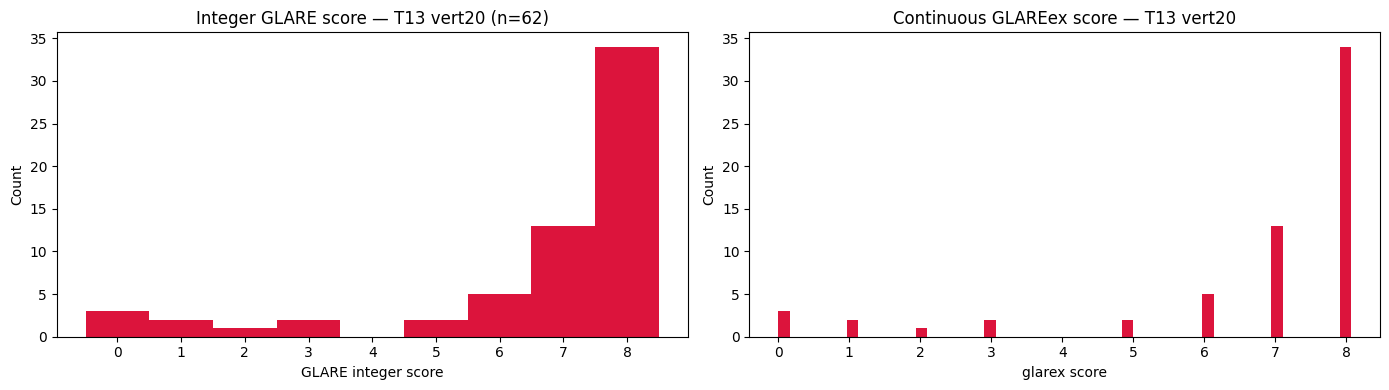

       glare score  glarex score
count    62.000000     62.000000
mean      6.661290      6.670004
std       2.275627      2.279607
min       0.000000      0.000224
25%       7.000000      7.000659
50%       8.000000      8.001367
75%       8.000000      8.007805
max       8.000000      8.069958


In [4]:
# ── Score distribution: T13 vert20 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bins = np.arange(-0.5, 9.5)

ax = axes[0]
ax.hist(t13_scores[INT_SCORE], bins=bins, color="crimson")
ax.set_xlabel("GLARE integer score")
ax.set_ylabel("Count")
ax.set_title(f"Integer GLARE score — T13 vert20 (n={len(t13_scores)})")
ax.set_xticks(range(9))

ax = axes[1]
ax.hist(t13_scores[SCORE_COL], bins=50, color="crimson")
ax.set_xlabel(SCORE_COL)
ax.set_ylabel("Count")
ax.set_title("Continuous GLAREex score — T13 vert20")

plt.tight_layout()
plt.show()

print(t13_scores[[INT_SCORE, SCORE_COL]].describe().to_string())

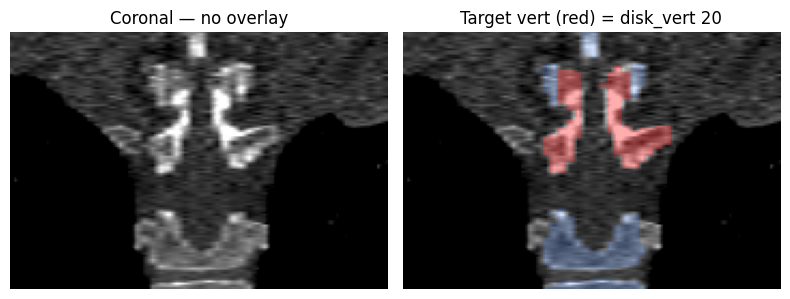

In [5]:
# ── Patch loading helpers ──────────────────────────────────────────────────────
def load_mid_slice(path, view="sagittal"):
    """Load central 2-D slice from a 3-D CT patch (H×W×D).
    view: 'sagittal'=axis 0, 'coronal'=axis 1, 'axial'=axis 2
    """
    d    = np.load(path, allow_pickle=True)
    img  = d["img"].astype(np.float32)
    axis = {"sagittal": 0, "coronal": 1, "axial": 2}[view]
    mid  = img.shape[axis] // 2
    slc  = np.take(img, mid, axis=axis)
    slc  = np.clip(slc, -200, 1000)
    slc  = (slc + 200) / 1200
    return slc

def load_mid_slice_with_mask(path, target_vert_id, view="coronal", alpha=0.35):
    """Load central slice and return (img_slice, overlay_rgba) where the
    target vertebra is highlighted in red and others in blue."""
    d    = np.load(path, allow_pickle=True)
    img  = d["img"].astype(np.float32)
    msk  = d["msk"]
    axis = {"sagittal": 0, "coronal": 1, "axial": 2}[view]
    mid  = img.shape[axis] // 2
    img_slc = np.take(img, mid, axis=axis)
    msk_slc = np.take(msk, mid, axis=axis)
    img_slc = np.clip(img_slc, -200, 1000)
    img_slc = (img_slc + 200) / 1200

    H, W = img_slc.shape
    overlay = np.zeros((H, W, 4), dtype=np.float32)
    # target vertebra: red
    target_mask = msk_slc == target_vert_id
    overlay[target_mask] = [1.0, 0.1, 0.1, alpha]
    # other vertebrae: blue
    other_mask = (msk_slc > 0) & ~target_mask
    overlay[other_mask] = [0.1, 0.4, 1.0, alpha * 0.5]
    return img_slc, overlay

# Quick sanity check
sample_row = t13_scores[t13_scores["patch_path"].notna()].iloc[0]
disk_v = int(sample_row["disk_vert_id"]) if pd.notna(sample_row["disk_vert_id"]) else int(sample_row["vert_id"])
img_slc, overlay = load_mid_slice_with_mask(sample_row["patch_path"], disk_v, "coronal")
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_slc, cmap="gray", origin="lower")
axes[0].set_title("Coronal — no overlay")
axes[0].axis("off")
axes[1].imshow(img_slc, cmap="gray", origin="lower")
axes[1].imshow(overlay, origin="lower")
axes[1].set_title(f"Target vert (red) = disk_vert {disk_v}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

Top row:    score ≤ 3  (n=4)
Bottom row: score = 8  (n=4)


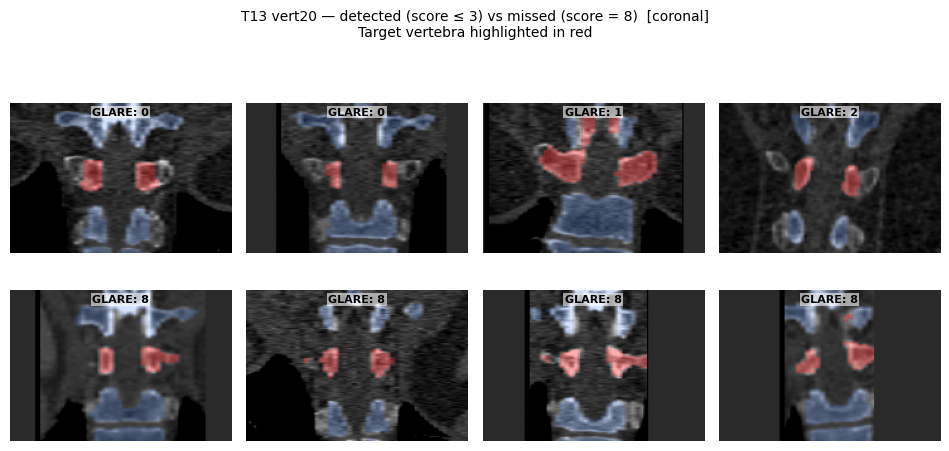

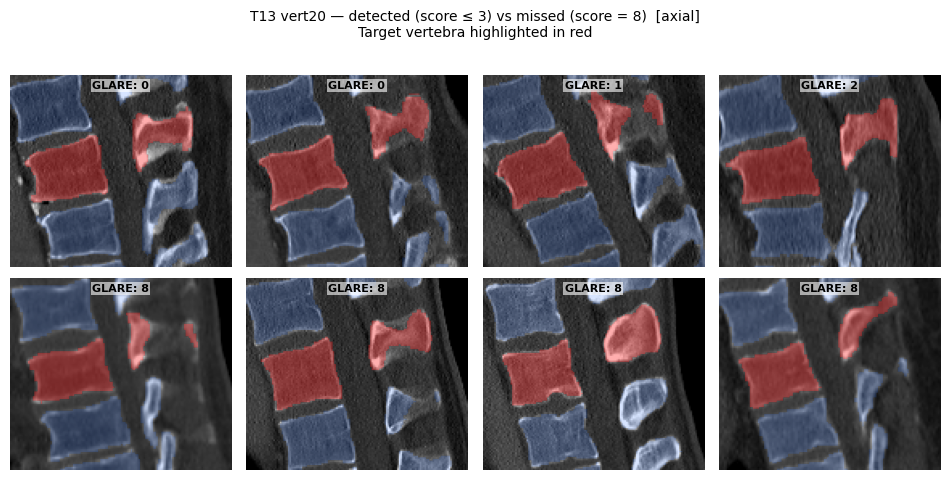

In [6]:
# ── Score ≤ 3 (skipping broken segs) vs score 8 (second group of 4) ──────────
NCOLS = 4

low  = t13_scores[t13_scores[INT_SCORE] <= 3].dropna(subset=["patch_path"]).sort_values(INT_SCORE).reset_index(drop=True)
high = t13_scores[t13_scores[INT_SCORE] == 8].dropna(subset=["patch_path"]).reset_index(drop=True)

# indices 0, 2, 3, 5 — skip 1 and 4 (broken segmentations)
LOW_IDX  = [0, 2, 3, 5]
row_low  = low.iloc[LOW_IDX].reset_index(drop=True)
row_high = high.iloc[NCOLS:NCOLS*2].reset_index(drop=True)

print(f"Top row:    score ≤ 3  (n={len(row_low)})")
print(f"Bottom row: score = 8  (n={len(row_high)})")

def plot_grid(view, save_path=None):
    fig, axes = plt.subplots(2, NCOLS, figsize=(NCOLS * 2.4, 2 * 2.5))
    for row_idx, (grp, colour, label) in enumerate([
        (row_low,  "lime", "score ≤ 3  (detected)"),
        (row_high, "red",  "score = 8  (missed)"),
    ]):
        for col in range(NCOLS):
            ax = axes[row_idx, col]
            if col < len(grp):
                r = grp.iloc[col]
                try:
                    disk_v = int(r["disk_vert_id"]) if pd.notna(r["disk_vert_id"]) else int(r["vert_id"])
                    img_slc, overlay = load_mid_slice_with_mask(r["patch_path"], disk_v, view)
                    ax.imshow(img_slc, cmap="gray", origin="lower")
                    ax.imshow(overlay, origin="lower")
                except Exception as e:
                    ax.text(0.5, 0.5, str(e), ha="center", va="center", fontsize=6)
                score_val = int(r[INT_SCORE]) if pd.notna(r[INT_SCORE]) else "?"
                ax.text(0.5, 0.97, f"GLARE: {score_val}", transform=ax.transAxes,
                        ha="center", va="top", fontsize=8, color="black", fontweight="bold",
                        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6, pad=1))
            ax.axis("off")
        axes[row_idx, 0].set_ylabel(label, fontsize=8, color=colour, rotation=90, labelpad=4)
    fig.suptitle(
        f"T13 vert20 — detected (score ≤ 3) vs missed (score = 8)  [{view}]\n"
        "Target vertebra highlighted in red",
        fontsize=10
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_grid("coronal",  "/home/student/lisa_ma/figures/T13_grid_coronal.jpg")
plot_grid("axial",    "/home/student/lisa_ma/figures/T13_grid_axial.jpg")

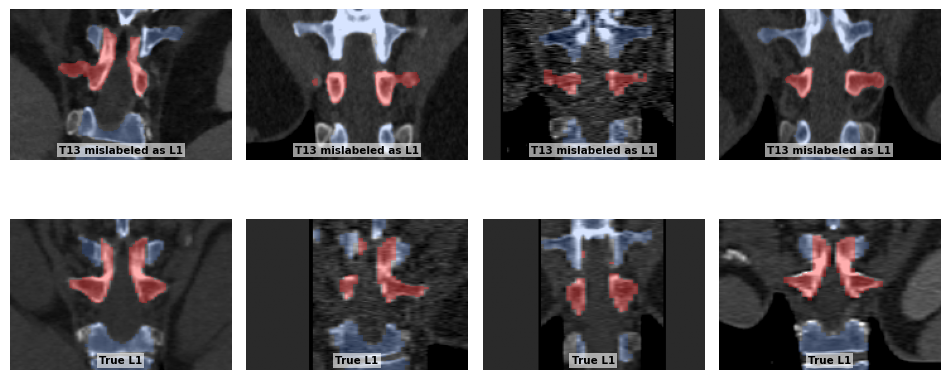

In [7]:
# ── Missed T13 (score=8) vs true L1 (non-T13 patients) ───────────────────────
NCOLS_CMP = 4

missed_t13 = (
    t13_scores[(t13_scores["vert_id"] == 20) & (t13_scores[INT_SCORE] == 8)]
    .dropna(subset=["patch_path"])
    .reset_index(drop=True)
)

gt_ids = set(pd.read_csv(GT_CSV)["sample_id"])
true_l1_scores = scores[
    scores["sample_id"].str.endswith("_vert20") &
    ~scores["sample_id"].isin(gt_ids)
].copy()

def pid_from_sid(sid):
    return "_".join(sid.split("_")[:-1])

true_l1_scores["pid"] = true_l1_scores["sample_id"].apply(pid_from_sid)
true_l1_scores["patch_path"] = true_l1_scores["pid"].apply(
    lambda p: get_patch_path(p, 20)
)
true_l1_scores = true_l1_scores.dropna(subset=["patch_path"]).reset_index(drop=True)

row_missed = missed_t13.iloc[:NCOLS_CMP].reset_index(drop=True)
row_true   = true_l1_scores.sample(NCOLS_CMP, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(2, NCOLS_CMP, figsize=(NCOLS_CMP * 2.4, 2 * 2.5))

for row_idx, (grp, patch_label) in enumerate([
    (row_missed, "T13 mislabeled as L1"),
    (row_true,   "True L1"),
]):
    for col in range(NCOLS_CMP):
        ax = axes[row_idx, col]
        if col < len(grp):
            r = grp.iloc[col]
            try:
                disk_v = int(r["disk_vert_id"]) if "disk_vert_id" in r and pd.notna(r["disk_vert_id"]) else 20
                img_slc, overlay = load_mid_slice_with_mask(r["patch_path"], disk_v, "coronal")
                ax.imshow(img_slc, cmap="gray", origin="lower")
                ax.imshow(overlay, origin="lower")
            except Exception as e:
                ax.text(0.5, 0.5, str(e), ha="center", va="center", fontsize=6)
            ax.text(0.5, 0.03, patch_label, transform=ax.transAxes,
                    ha="center", va="bottom", fontsize=7.5, color="black", fontweight="bold",
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.6, pad=1.5))
        ax.axis("off")

plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/T13_vs_L1_comparison.jpg", dpi=300, bbox_inches="tight")
plt.show()

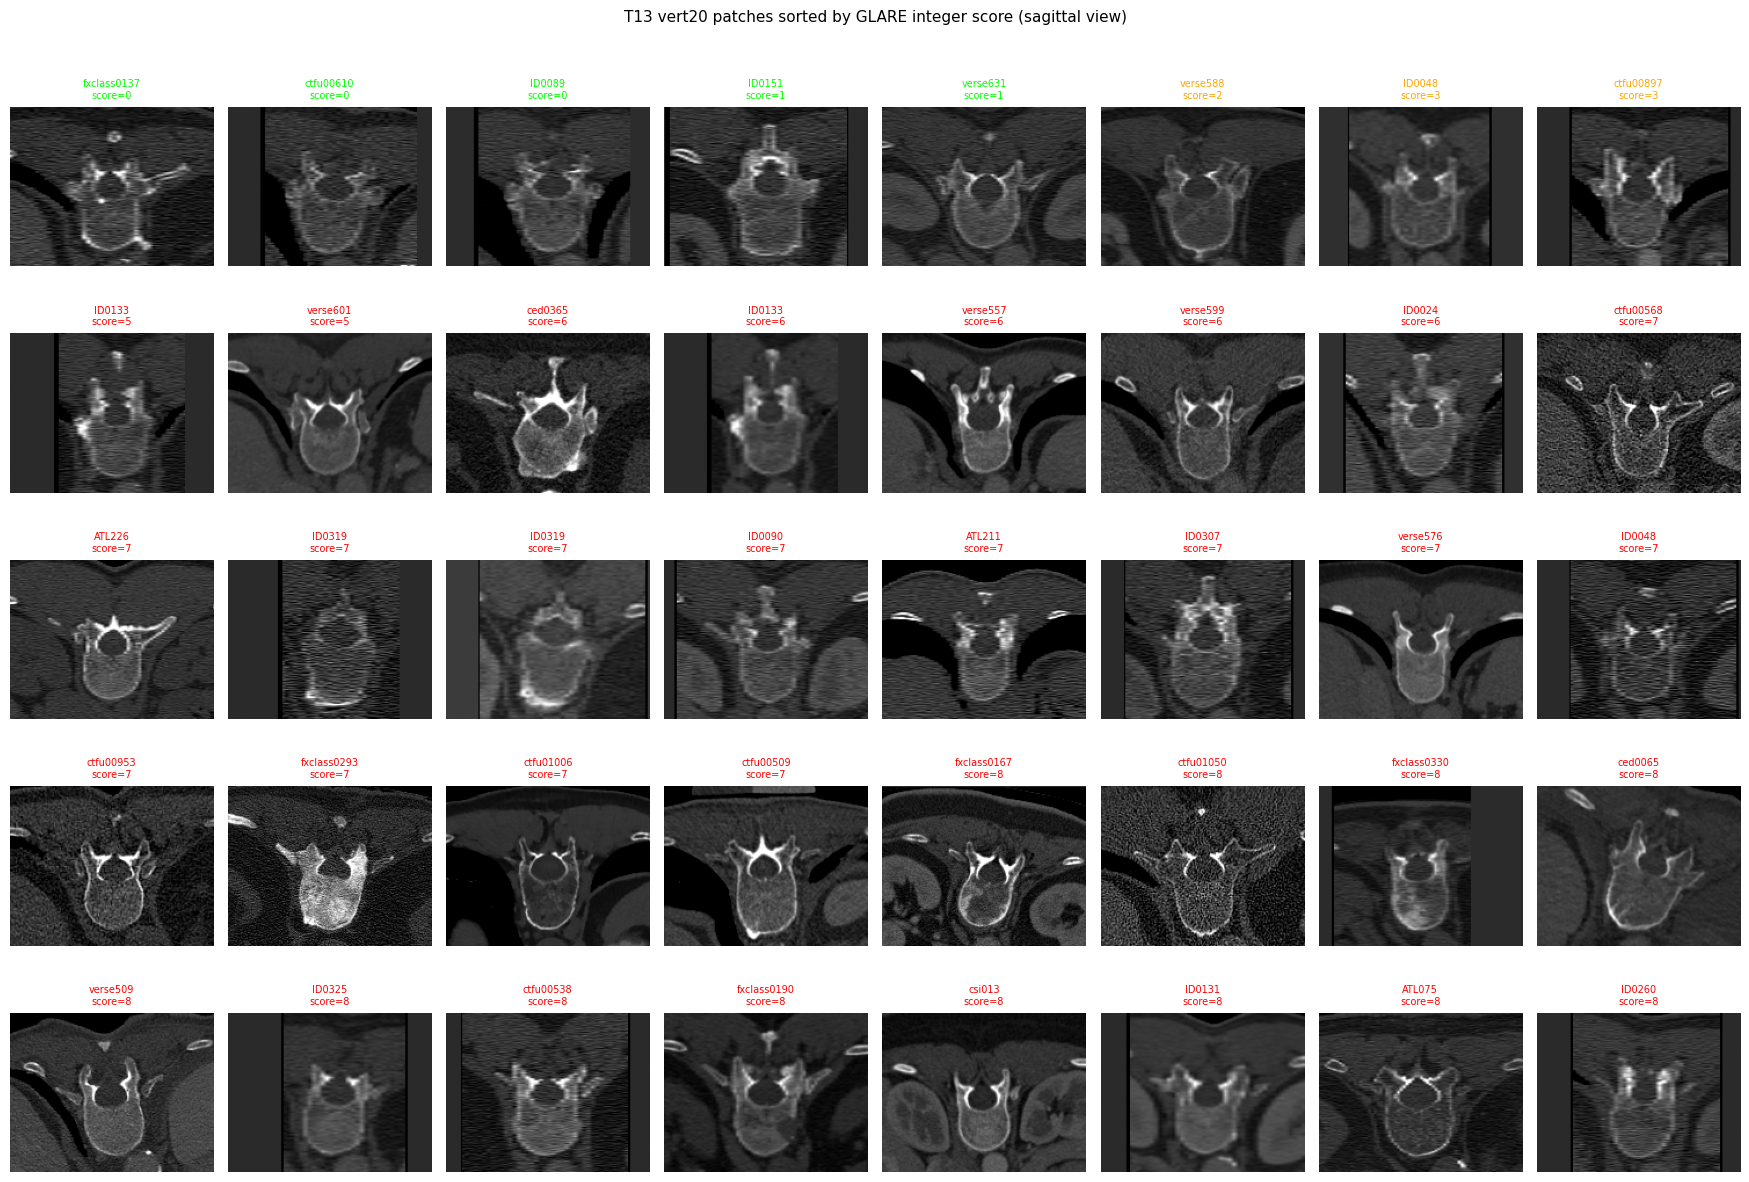

Shown: 40  |  green=detected (≤1), orange=partial (≤3), red=missed (>3)


In [8]:
# ── Grid: T13 vert20 patches sorted by GLARE score (low → detected, high → missed)
VIEW = "sagittal"  # change to 'coronal' or 'axial' if sagittal doesn't look right
MAX_SHOW = 40      # max patches to display

subset = (
    t13_scores[t13_scores["vert_id"]==20]
    .dropna(subset=["patch_path"])
    .sort_values(INT_SCORE)
    .reset_index(drop=True)
)
subset = subset.head(MAX_SHOW)

ncols = 8
nrows = int(np.ceil(len(subset) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.2, nrows * 2.4))
axes = np.array(axes).flatten()

for i, (_, row) in enumerate(subset.iterrows()):
    ax = axes[i]
    try:
        slc = load_mid_slice(row["patch_path"], VIEW)
        ax.imshow(slc, cmap="gray", origin="lower")
    except Exception as e:
        ax.text(0.5, 0.5, str(e), ha="center", va="center", fontsize=6)
    pid_short = row["pid"].split("_")[0]
    score_int = int(row[INT_SCORE])
    colour = "lime" if score_int <= 1 else ("orange" if score_int <= 3 else "red")
    ax.set_title(f"{pid_short}\nscore={score_int}", fontsize=7, color=colour)
    ax.axis("off")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"T13 vert20 patches sorted by GLARE integer score ({VIEW} view)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()
print(f"Shown: {len(subset)}  |  green=detected (≤1), orange=partial (≤3), red=missed (>3)")

Detected (score 0): 3
Missed   (score 8): 34


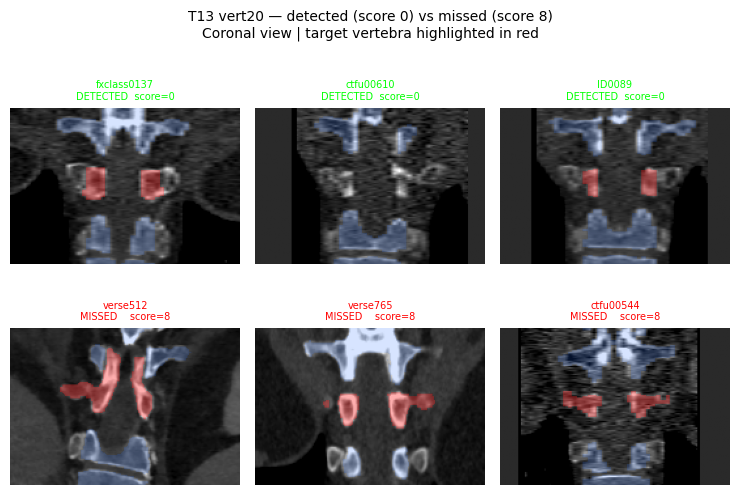

In [9]:
# ── Side-by-side: detected (score 0) vs missed (score 8) vert20 ───────────────
# Coronal view with target vertebra highlighted in red
VIEW = "coronal"

detected = t13_scores[(t13_scores["vert_id"]==20) & (t13_scores[INT_SCORE]==0)].dropna(subset=["patch_path"])
missed   = t13_scores[(t13_scores["vert_id"]==20) & (t13_scores[INT_SCORE]==8)].dropna(subset=["patch_path"])

print(f"Detected (score 0): {len(detected)}")
print(f"Missed   (score 8): {len(missed)}")

n = min(5, len(detected), len(missed))
fig, axes = plt.subplots(2, n, figsize=(n * 2.5, 5.5))

for col in range(n):
    for row_idx, (grp, colour, label) in enumerate([
        (detected, "lime", "DETECTED  score=0"),
        (missed,   "red",  "MISSED    score=8"),
    ]):
        r        = grp.iloc[col]
        ax       = axes[row_idx, col]
        disk_v   = int(r["disk_vert_id"]) if pd.notna(r["disk_vert_id"]) else int(r["vert_id"])
        img_slc, overlay = load_mid_slice_with_mask(r["patch_path"], disk_v, VIEW)
        ax.imshow(img_slc, cmap="gray", origin="lower")
        ax.imshow(overlay, origin="lower")
        pid_short = r["pid"].split("_")[0]
        ax.set_title(f"{pid_short}\n{label}", fontsize=7, color=colour)
        ax.axis("off")

fig.suptitle(
    "T13 vert20 — detected (score 0) vs missed (score 8)\n"
    "Coronal view | target vertebra highlighted in red",
    fontsize=10
)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/T13_detected_vs_missed_coronal.jpg", dpi=300, bbox_inches="tight")
plt.show()

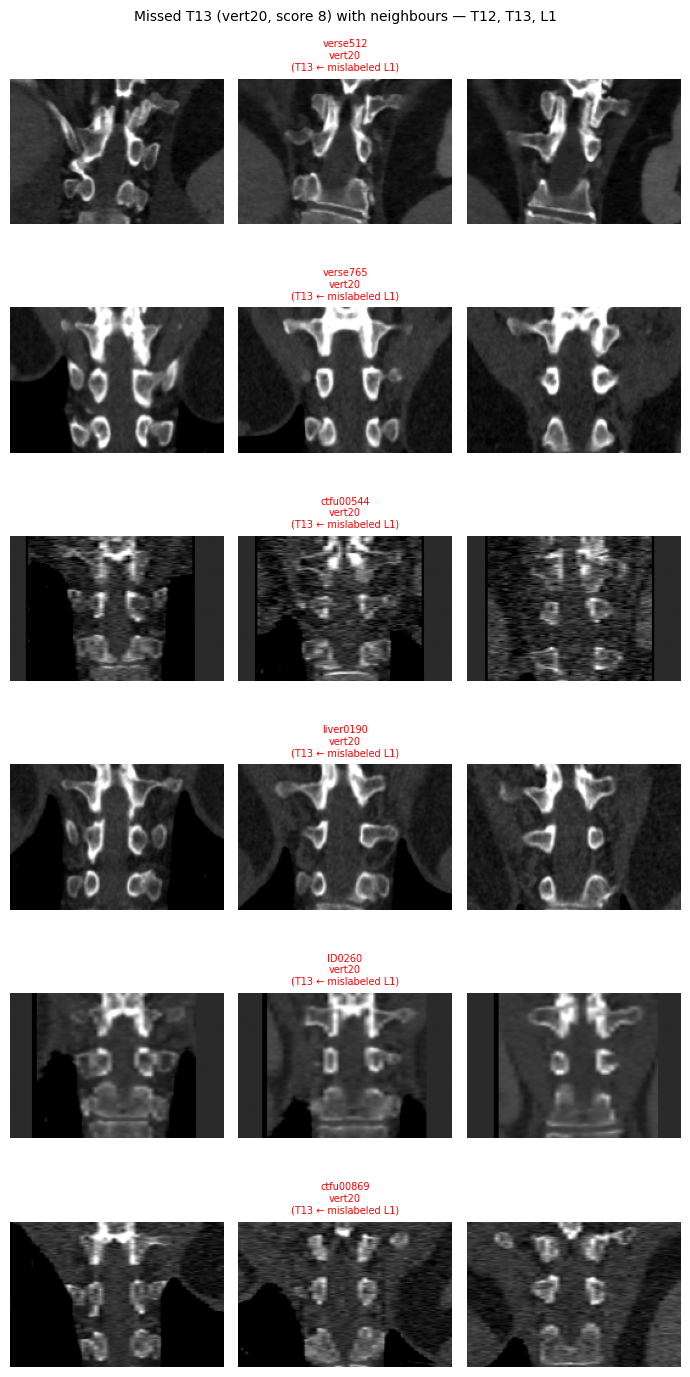

In [10]:
# ── Neighbour comparison: T13 vert20 next to vert19 (true T12) and vert21 (true L1)
# For a missed T13 case, load vert19 and vert21 neighbours to see visual similarity

def get_neighbour_path(pid, training_vert):
    """Load file path for an arbitrary training_vert of a given PID."""
    if pid not in pid_meta:
        return None
    meta = pid_meta[pid]
    # For this PID get its correction map to find disk_vert for training_vert
    if pid in (pid_fix_1820 | pid_fix_28):
        corr = apply_rules(meta["disk_verts"])
        inv  = {tv: dv for dv, tv in corr.items()}
    else:
        inv  = {v: v for v in meta["disk_verts"]}
    disk_v = inv.get(training_vert)
    if disk_v is None:
        return None
    p = PREPARED / meta["dsname"] / meta["split"] / f"segment0.8mm_vert{disk_v}_sub-{pid}.npz"
    return p if p.exists() else None

# Pick a few missed T13 cases and show vert19, vert20 (T13), vert21 side by side
missed_sample = t13_scores[
    (t13_scores["vert_id"]==20) & (t13_scores[INT_SCORE]==8)
].dropna(subset=["patch_path"]).head(6)

n = len(missed_sample)
fig, axes = plt.subplots(n, 3, figsize=(7, n * 2.4))
if n == 1:
    axes = axes[np.newaxis, :]

for row_i, (_, r) in enumerate(missed_sample.iterrows()):
    pid = r["pid"]
    pid_short = pid.split("_")[0]
    for col_i, (tv, vtitle) in enumerate([(19, "vert19\n(T12)"), (20, "vert20\n(T13 ← mislabeled L1)"), (21, "vert21\n(L1)")]):
        ax = axes[row_i, col_i]
        if tv == 20:
            p = r["patch_path"]
        else:
            p = get_neighbour_path(pid, tv)
        if p and Path(p).exists():
            slc = load_mid_slice(p, VIEW)
            ax.imshow(slc, cmap="gray", origin="lower")
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center")
        colour = "red" if tv == 20 else "white"
        ax.set_title(f"{pid_short}\n{vtitle}", fontsize=7, color=colour)
        ax.axis("off")

fig.suptitle("Missed T13 (vert20, score 8) with neighbours — T12, T13, L1", fontsize=10)
plt.tight_layout()
plt.show()

In [11]:
# ── What alternative class does GLARE suggest for T13 samples? ─────────────────
INT_TO_CLASS = {0: "Cervical", 1: "Thoracic", 2: "Lumbar", 3: "Sacral"}

t13_v20 = t13_scores[t13_scores["vert_id"]==20].copy()
t13_v20["alt_class_name"] = t13_v20["alternative class (glarex)"].map(INT_TO_CLASS)

print("Alternative class suggested by GLARE for T13 vert20 (true class = Thoracic):")
print(t13_v20.groupby([INT_SCORE, "alt_class_name"]).size().to_string())

# When GLARE score=8 (confident Lumbar), it means the model is very sure it's Lumbar.
# The T13 vertebra looks exactly like a lumbar vertebra → GLARE cannot detect it.
# When score=0, the alternative class should ideally be Thoracic.
print()
detected_alt = t13_v20[t13_v20[INT_SCORE]<=2]["alt_class_name"].value_counts()
print("Alternative class for detected T13 vert20 (score ≤ 2):")
print(detected_alt.to_string())

Alternative class suggested by GLARE for T13 vert20 (true class = Thoracic):
glare score  alt_class_name
0            Thoracic           3
1            Thoracic           2
2            Thoracic           1
3            Thoracic           2
5            Thoracic           2
6            Thoracic           5
7            Cervical           2
             Thoracic          11
8            Sacral             7
             Thoracic          27

Alternative class for detected T13 vert20 (score ≤ 2):
alt_class_name
Thoracic    6


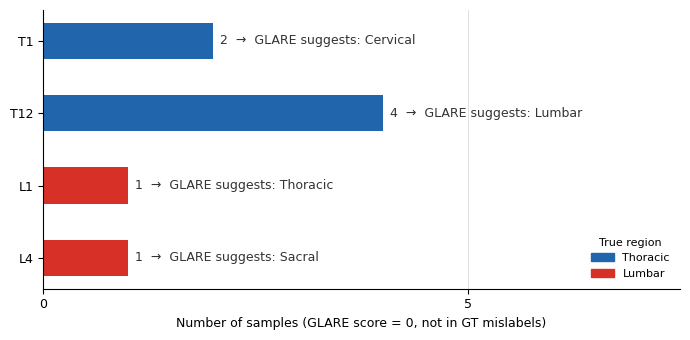

True positives (in GT): 10  |  False positives (not GT): 8
vert_name true_region alt_class  count
       L1      Lumbar  Thoracic      1
       L4      Lumbar    Sacral      1
       T1    Thoracic  Cervical      2
      T12    Thoracic    Lumbar      4


In [12]:
# ── Score=0 false positives: vertebra distribution ──────────────────────────
CLASS_NAME = {0: "Cervical", 1: "Thoracic", 2: "Lumbar", 3: "Sacral"}
VERT_NAME  = {8: "T1", 19: "T12", 20: "L1", 24: "L4"}
REGION_COLOR = {"Thoracic": "#2166ac", "Lumbar": "#d73027"}
REGION_OF    = {8: "Thoracic", 19: "Thoracic", 20: "Lumbar", 24: "Lumbar"}

score0_all = scores[scores[INT_SCORE] == 0].copy()
gt_ids     = set(pd.read_csv(GT_CSV)["sample_id"])
fp         = score0_all[~score0_all["sample_id"].isin(gt_ids)].copy()
tp         = score0_all[ score0_all["sample_id"].isin(gt_ids)].copy()

fp["vert_id"]      = fp["sample_id"].str.extract(r"_vert(\d+)$").astype(int)
fp["vert_name"]    = fp["vert_id"].map(VERT_NAME)
fp["true_region"]  = fp["vert_id"].map(REGION_OF)
fp["alt_class"]    = fp["alternative class (glarex)"].map(CLASS_NAME)

vert_order = ["T1", "T12", "L1", "L4"]
counts = fp.groupby("vert_name").size().reindex(vert_order).fillna(0).astype(int)
alt_label = (
    fp.groupby("vert_name")["alt_class"]
    .agg(lambda x: x.mode()[0])
    .reindex(vert_order)
)

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(vert_order[::-1], counts[vert_order[::-1]],
               color=[REGION_COLOR[REGION_OF[{v: k for k, v in VERT_NAME.items()}[vn]]] for vn in vert_order[::-1]],
               height=0.5, linewidth=0)

for bar, vn in zip(bars, vert_order[::-1]):
    n   = int(counts[vn])
    alt = alt_label[vn]
    ax.text(bar.get_width() + 0.08, bar.get_y() + bar.get_height() / 2,
            f"{n}  →  GLARE suggests: {alt}",
            va="center", fontsize=9, color="#333333")

ax.set_xlim(0, 7.5)
ax.set_xlabel("Number of samples (GLARE score = 0, not in GT mislabels)", fontsize=9)
ax.tick_params(axis="both", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks([0, 5])
ax.grid(axis="x", color="#e0e0e0", linewidth=0.7, zorder=0)

from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=r) for r, c in REGION_COLOR.items()]
ax.legend(handles=legend_handles, title="True region", fontsize=8,
          title_fontsize=8, loc="lower right", frameon=False)

plt.tight_layout()
plt.show()

print(f"True positives (in GT): {len(tp)}  |  False positives (not GT): {len(fp)}")
print(fp.groupby(["vert_name","true_region","alt_class"]).size()
        .rename("count").reset_index().to_string(index=False))

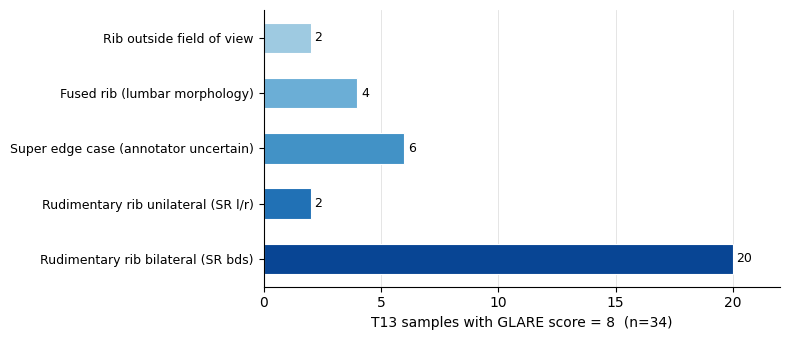

In [13]:
# ── Missed T13 (score=8): annotation-based category breakdown ────────────────
_anom = pd.read_excel(Path("../evaluation/A_CT_ANOMALY_LABELv9.xlsx"))
_anom["scan_base"] = _anom["fid"]   # full fid — no split stripping
_anom_best = _anom.drop_duplicates("scan_base")

_t13_sc = scores.merge(
    pd.read_csv(GT_CSV).query("anomaly_type=='T13_extra' and vert_id==20")[["sample_id"]],
    on="sample_id", how="inner"
)
_missed8 = _t13_sc[_t13_sc[INT_SCORE] == 8].copy()
_missed8["scan_base"] = _missed8["sample_id"].str.replace(r"_vert\d+$", "", regex=True)
_missed8 = _missed8.merge(_anom_best[["scan_base", "HE Comment"]], on="scan_base", how="left")

def _cat(c):
    if pd.isna(c): return None
    c = str(c)
    if "SUPER EDGE CASE" in c:  return "Super edge case (annotator uncertain)"
    if "Type 4" in c:            return "Fused rib (lumbar morphology)"
    if "abgeschnitten" in c:     return "Rib outside field of view"
    if "bleibt T12" in c:        return "Rib seen, kept as T12"
    if "bds" in c:               return "Rudimentary rib bilateral (SR bds)"
    if "SR" in c:                return "Rudimentary rib unilateral (SR l/r)"
    return None

CAT_ORDER_B = [
    "Rudimentary rib bilateral (SR bds)",
    "Rudimentary rib unilateral (SR l/r)",
    "Super edge case (annotator uncertain)",
    "Fused rib (lumbar morphology)",
    "Rib outside field of view",
    "Rib seen, kept as T12",
]
CAT_COLORS_B = {
    "Rudimentary rib bilateral (SR bds)":    "#084594",
    "Rudimentary rib unilateral (SR l/r)":   "#2171b5",
    "Super edge case (annotator uncertain)":  "#4292c6",
    "Fused rib (lumbar morphology)":          "#6baed6",
    "Rib outside field of view":              "#9ecae1",
    "Rib seen, kept as T12":                  "#c6dbef",
}

_missed8["category"] = _missed8["HE Comment"].apply(_cat)
_missed8 = _missed8.dropna(subset=["category"])
_counts_b = (_missed8["category"].value_counts()
             .reindex([c for c in CAT_ORDER_B if c in _missed8["category"].unique()]))

fig, ax = plt.subplots(figsize=(8, 3.5))
y = np.arange(len(_counts_b))
ax.grid(axis="x", color="#e0e0e0", linewidth=0.6, zorder=1)
bars = ax.barh(y, _counts_b.values,
               color=[CAT_COLORS_B[c] for c in _counts_b.index],
               height=0.55, edgecolor="white", linewidth=0.8, zorder=3)

for bar in bars:
    w = bar.get_width()
    if w > 0:
        ax.text(w + 0.15, bar.get_y() + bar.get_height() / 2,
                str(int(w)), va="center", fontsize=9, zorder=4)

ax.set_yticks(y)
ax.set_yticklabels(_counts_b.index, fontsize=9)
ax.set_xlabel(f"T13 samples with GLARE score = 8  (n={len(_missed8)})", fontsize=10)
ax.set_xlim(0, _counts_b.max() + 2)
ax.set_xticks(range(0, int(_counts_b.max()) + 5, 5))
ax.spines[["top", "right"]].set_visible(False)
ax.spines["left"].set_zorder(4)
ax.spines["bottom"].set_zorder(4)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/missed_T13_categories_bar.jpg", dpi=300, bbox_inches="tight")
plt.show()

Score ≤ 3 False Positives — Categories:
            category  samples  scans
                TLTV        2      2
             No ribs        4      4
Segmentation failure        4      1
          No anomaly        4      3
       Metal implant        1      1
       Not annotated       23     22

Total: 38 samples from 33 scans


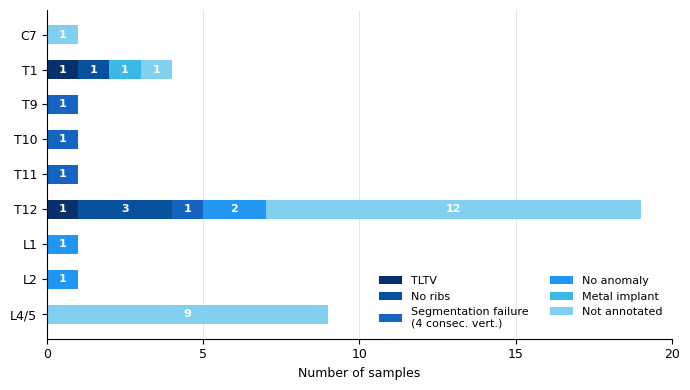

In [14]:
# ── Score ≤ 3 false positives — vertebra distribution + anomaly categories ──
ANOM_XLS = Path("../evaluation/A_CT_ANOMALY_LABELv9.xlsx")

anom = pd.read_excel(ANOM_XLS)
anom["scan_base"] = anom["fid"].str.replace(r"_split-\S+$", "", regex=True)
anom_best = anom.sort_values("TLTV", ascending=False).drop_duplicates("scan_base")

fp3 = scores[scores[INT_SCORE] <= 3].copy()
fp3 = fp3[~fp3["sample_id"].isin(set(pd.read_csv(GT_CSV)["sample_id"]))]
fp3["vert_id"]   = fp3["sample_id"].str.extract(r"_vert(\d+)$").astype(int)
fp3["scan_base"] = fp3["sample_id"].str.replace(r"_vert\d+$", "", regex=True)

fp3 = fp3.merge(
    anom_best[["scan_base", "T11", "T13", "TLTV", "LabelOverride", "HE Comment"]],
    on="scan_base", how="left"
)

def assign_category(row):
    comment = str(row.get("HE Comment", "") or "")
    if row.get("TLTV") == 1:
        return "TLTV"
    if "Rippen" in comment or "rippen" in comment:
        return "No ribs"
    if "segfail" in comment.lower():
        return "Segmentation failure"
    if "Passt" in comment or "passt" in comment:
        return "No anomaly"
    if pd.notna(row.get("HE Comment")):
        return "Metal implant"
    return "Not annotated"

fp3["category"] = fp3.apply(assign_category, axis=1)

CAT_ORDER  = ["TLTV", "No ribs", "Segmentation failure", "No anomaly", "Metal implant", "Not annotated"]
CAT_COLORS = {
    "TLTV":                  "#08306b",  # deepest navy
    "No ribs":               "#08519c",  # dark blue
    "Segmentation failure":  "#1565c0",  # vivid medium-dark blue
    "No anomaly":            "#2196f3",  # bright vivid blue
    "Metal implant":         "#3ab8e8",  # vivid sky blue
    "Not annotated":         "#82d0f0",  # light blue
}
CAT_LEGEND = {
    "TLTV":                  "TLTV",
    "No ribs":               "No ribs",
    "Segmentation failure":  "Segmentation failure\n(4 consec. vert.)",
    "No anomaly":            "No anomaly",
    "Metal implant":         "Metal implant",
    "Not annotated":         "Not annotated",
}

cat_summary = (
    fp3.groupby("category")
    .agg(samples=("sample_id", "count"), scans=("scan_base", "nunique"))
    .reindex([c for c in CAT_ORDER if c in fp3["category"].unique()])
    .reset_index()
)
print("Score ≤ 3 False Positives — Categories:")
print(cat_summary[["category", "samples", "scans"]].to_string(index=False))
print(f"\nTotal: {len(fp3)} samples from {fp3['scan_base'].nunique()} scans")

VERT_LABEL = {7: "C7", 8: "T1", 16: "T9", 17: "T10", 18: "T11", 19: "T12", 20: "L1", 21: "L2", 24: "L4/5"}

vert_cat = (
    fp3.assign(vert_label=fp3["vert_id"].map(VERT_LABEL).fillna(fp3["vert_id"].astype(str)))
    .groupby(["vert_label", "category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[c for c in CAT_ORDER if c in fp3["category"].unique()])
)
# Lumbar at bottom, thoracic in middle, cervical at top
vert_order_plot = ["L4/5", "L2", "L1", "T12", "T11", "T10", "T9", "T1", "C7"]
vert_order_plot = [v for v in vert_order_plot if v in vert_cat.index]
vert_cat = vert_cat.reindex(vert_order_plot)

fig, ax_bar = plt.subplots(figsize=(7, 4))
ax_bar.grid(axis="x", color="#e0e0e0", linewidth=0.6, zorder=1)

lefts = [0] * len(vert_cat)
for cat in vert_cat.columns:
    vals = vert_cat[cat].values
    bars = ax_bar.barh(vert_cat.index, vals, left=lefts,
                       color=CAT_COLORS[cat], label=CAT_LEGEND[cat], height=0.55, zorder=3)
    for bar, v, l in zip(bars, vals, lefts):
        if v > 0:
            ax_bar.text(l + v / 2, bar.get_y() + bar.get_height() / 2,
                        str(v), ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold", zorder=4)
    lefts = [l + v for l, v in zip(lefts, vals)]

ax_bar.set_xlabel("Number of samples", fontsize=9)
ax_bar.set_xlim(0, 20)
ax_bar.set_xticks(range(0, 21, 5))
ax_bar.spines[["top", "right"]].set_visible(False)
ax_bar.spines["left"].set_zorder(4)
ax_bar.spines["bottom"].set_zorder(4)
ax_bar.tick_params(labelsize=9)
ax_bar.legend(fontsize=8, loc="lower right", frameon=False, ncol=2)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/score0_categories_bar.jpg", dpi=300, bbox_inches="tight")
plt.show()

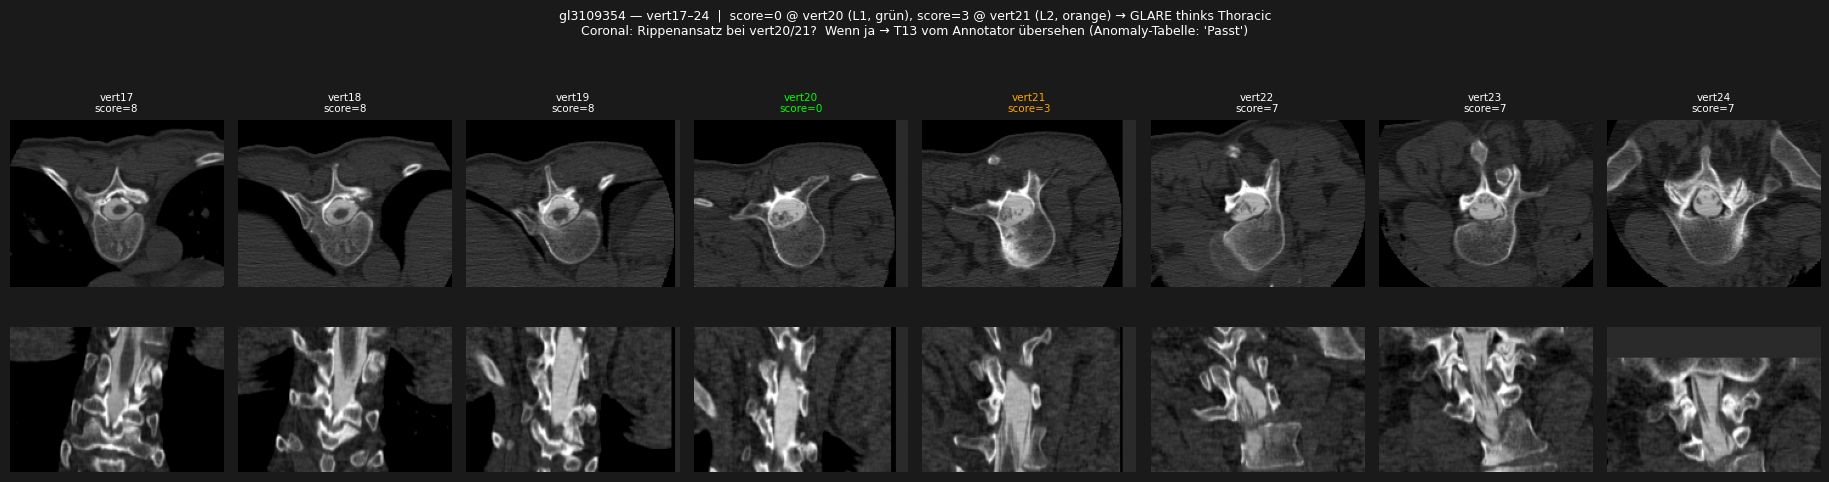

In [15]:
# ── gl3109354: möglicher unentdeckter T13 — Patches vert17-24 ──────────────
# GLARE score=0 an vert20 (L1) und score=3 an vert21 (L2), beide → GLARE denkt Thoracic
# Hypothese: T13 vorhanden, annotiert als "Passt" → möglicher GT-Fehler

PID_GL  = "gl3109354"
DNAME   = "dataset-CSILabel"
SPLIT   = "train"
VERTS   = list(range(17, 25))   # T10–L5: Kontext + verdächtige Wirbel

gl_scores = {
    int(r["sample_id"].split("_vert")[-1]): int(r[INT_SCORE])
    for _, r in scores[scores["sample_id"].str.startswith(PID_GL)].iterrows()
}

fig, axes = plt.subplots(2, len(VERTS), figsize=(len(VERTS) * 2.3, 5.2))

for col, v in enumerate(VERTS):
    path = PREPARED / DNAME / SPLIT / f"segment0.8mm_vert{v}_sub-{PID_GL}.npz"
    score_int = gl_scores.get(v)

    for row, view in enumerate(["sagittal", "coronal"]):
        ax = axes[row, col]
        if path.exists():
            slc = load_mid_slice(path, view)
            ax.imshow(slc, cmap="gray", origin="lower")
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", color="white")

        if row == 0:
            colour = "lime" if score_int is not None and score_int <= 1 \
                     else ("orange" if score_int is not None and score_int <= 3 else "white")
            ax.set_title(f"vert{v}\nscore={score_int}", fontsize=7.5, color=colour)
        if col == 0:
            ax.set_ylabel(view, fontsize=7, rotation=0, labelpad=36, va="center", color="white")
        ax.axis("off")

fig.patch.set_facecolor("#1a1a1a")
for ax in axes.flat:
    ax.set_facecolor("#1a1a1a")

fig.suptitle(
    "gl3109354 — vert17–24  |  score=0 @ vert20 (L1, grün), score=3 @ vert21 (L2, orange) → GLARE thinks Thoracic\n"
    "Coronal: Rippenansatz bei vert20/21?  Wenn ja → T13 vom Annotator übersehen (Anomaly-Tabelle: 'Passt')",
    fontsize=9, color="white", y=1.02
)
plt.tight_layout()
plt.show()

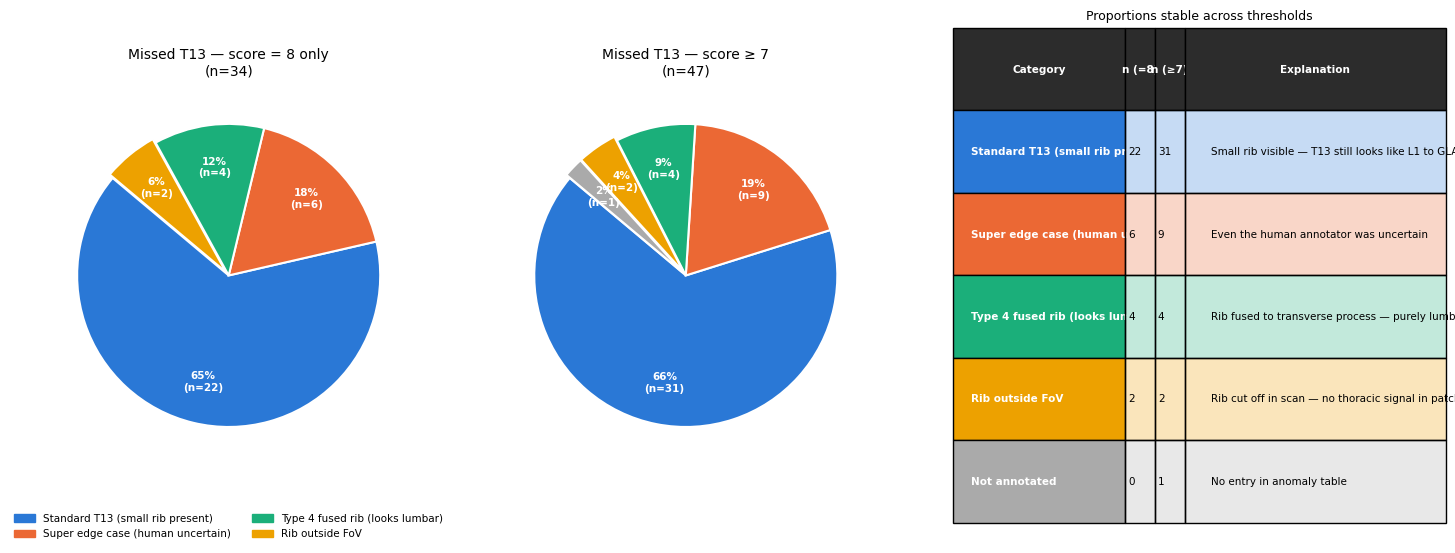

In [16]:
# ── Missed T13: pie chart breakdown — score=8 vs score≥7 ─────────────────────
_anom_xls = Path("../evaluation/A_CT_ANOMALY_LABELv9.xlsx")
_anom_all = pd.read_excel(_anom_xls)
_anom_all["scan_base"] = _anom_all["fid"]   # full fid — no split stripping, avoids ATL join bug
_anom_best = _anom_all.drop_duplicates("scan_base")

gt_all = pd.read_csv(GT_CSV)
t13_gt = gt_all[(gt_all["anomaly_type"] == "T13_extra") & (gt_all["vert_id"] == 20)]
t13_sc  = scores.merge(t13_gt[["sample_id"]], on="sample_id", how="inner")

def cat_missed(c):
    if pd.isna(c): return "Not annotated"
    c = str(c)
    if "SUPER EDGE CASE" in c: return "Super edge case\n(human uncertain)"
    if "Type 4" in c:          return "Type 4 fused rib\n(looks lumbar)"
    if "abgeschnitten" in c:   return "Rib outside FoV"
    if "bleibt T12" in c:      return "Rib seen,\nkept as T12"
    if "SR" in c:              return "Standard T13\n(small rib present)"
    return "Not annotated"

CAT_ORDER_EN = [
    "Standard T13\n(small rib present)",
    "Super edge case\n(human uncertain)",
    "Type 4 fused rib\n(looks lumbar)",
    "Rib outside FoV",
    "Rib seen,\nkept as T12",
    "Not annotated",
]
CAT_COLORS_EN = {
    "Standard T13\n(small rib present)":  "#2a78d6",
    "Super edge case\n(human uncertain)":  "#eb6834",
    "Type 4 fused rib\n(looks lumbar)":    "#1baf7a",
    "Rib outside FoV":                     "#eda100",
    "Rib seen,\nkept as T12":              "#e87ba4",
    "Not annotated":                       "#aaaaaa",
}
CAT_EXP_EN = {
    "Standard T13\n(small rib present)":  "Small rib visible — T13 still looks like L1 to GLARE",
    "Super edge case\n(human uncertain)":  "Even the human annotator was uncertain",
    "Type 4 fused rib\n(looks lumbar)":    "Rib fused to transverse process — purely lumbar morphology",
    "Rib outside FoV":                     "Rib cut off in scan — no thoracic signal in patch",
    "Rib seen,\nkept as T12":              "Annotator saw rib but classified as T12 (boundary decision)",
    "Not annotated":                       "No entry in anomaly table",
}

def get_counts(threshold):
    missed = t13_sc[t13_sc[INT_SCORE] >= threshold].copy()
    missed["scan_base"] = missed["sample_id"].str.replace(r"_vert\d+$", "", regex=True)
    missed = missed.merge(_anom_best[["scan_base", "HE Comment"]], on="scan_base", how="left")
    missed["category"] = missed["HE Comment"].apply(cat_missed)
    return (missed.groupby("category").size()
            .reindex([c for c in CAT_ORDER_EN if c in missed["category"].unique()])
            .dropna().astype(int)), len(missed)

counts8,  n8  = get_counts(8)
counts7,  n7  = get_counts(7)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5),
                         gridspec_kw={"width_ratios": [1, 1, 1.3]})

for ax, counts, n, title in [
    (axes[0], counts8, n8, f"score = 8 only\n(n={n8})"),
    (axes[1], counts7, n7, f"score ≥ 7\n(n={n7})"),
]:
    colors  = [CAT_COLORS_EN[c] for c in counts.index]
    explode = [0.03 if v <= 2 else 0 for v in counts.values]
    wedges, _, autotexts = ax.pie(
        counts.values, labels=None, colors=colors, explode=explode,
        autopct=lambda p: f"{p:.0f}%\n(n={p/100*n:.0f})",
        pctdistance=0.72, startangle=140,
        wedgeprops={"linewidth": 1.5, "edgecolor": "white"},
    )
    for at in autotexts:
        at.set_fontsize(7.5)
        at.set_color("white")
        at.set_fontweight("bold")
    ax.set_title(f"Missed T13 — {title}", fontsize=10, pad=8)

axes[0].legend(
    [plt.matplotlib.patches.Patch(color=CAT_COLORS_EN[c]) for c in counts8.index],
    [c.replace("\n", " ") for c in counts8.index],
    loc="lower center", bbox_to_anchor=(0.5, -0.22),
    fontsize=7.5, frameon=False, ncol=2,
)

ax_tbl = axes[2]
ax_tbl.axis("off")
tbl_rows = [
    [c.replace("\n", " "),
     str(counts8.get(c, 0)),
     str(counts7.get(c, 0)),
     CAT_EXP_EN[c]]
    for c in CAT_ORDER_EN if c in counts8.index or c in counts7.index
]
tbl = ax_tbl.table(
    cellText=tbl_rows,
    colLabels=["Category", "n (=8)", "n (≥7)", "Explanation"],
    cellLoc="left", loc="center", bbox=[0, 0, 1, 1],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.auto_set_column_width([0, 1, 2, 3])
for j in range(4):
    tbl[0, j].set_facecolor("#2c2c2c")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i, row in enumerate(tbl_rows):
    cat = next((c for c in CAT_ORDER_EN if c.replace("\n", " ") == row[0]), None)
    c = CAT_COLORS_EN.get(cat, "#ffffff")
    for j in range(4): tbl[i+1, j].set_facecolor(c + "44")
    tbl[i+1, 0].set_facecolor(c)
    tbl[i+1, 0].set_text_props(color="white", fontweight="bold")

ax_tbl.set_title("Proportions stable across thresholds", fontsize=9, pad=6)
plt.tight_layout()
plt.show()

SUPER EDGE CASE Einträge in Anomaly-Tabelle: 17
  im GLARE-CSV (Trainingsset): 10  |  nicht drin (Test/anderer Split): 7

Score-Verteilung (n=10):
  score 6: █ (1)
  score 7: ███ (3)
  score 8: ██████ (6)

Detektiert (score ≤ 3): 0 / 10  →  0%


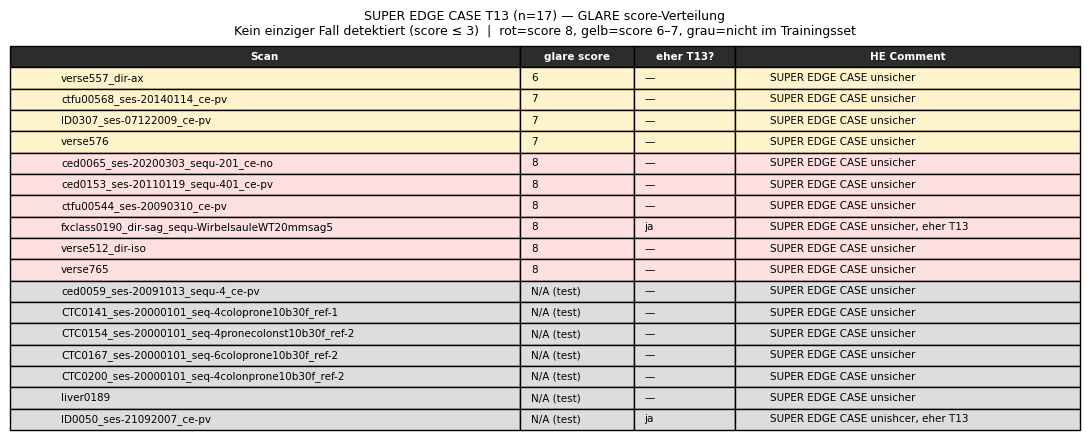

In [17]:
# ── SUPER EDGE CASE: Wie viele gibt es, und wie erkennt GLARE sie? ────────────
_anom_xls = Path("../evaluation/A_CT_ANOMALY_LABELv9.xlsx")
_anom_all = pd.read_excel(_anom_xls)
_anom_all["scan_base"] = _anom_all["fid"].str.replace(r"_split-\S+$", "", regex=True)

sec = _anom_all[_anom_all["HE Comment"].str.contains("SUPER EDGE CASE", na=False)].copy()
sec["sample_id"] = sec["scan_base"] + "_vert" + sec["vert"].astype(int).astype(str)
sec = sec.merge(scores[["sample_id", INT_SCORE, SCORE_COL]], on="sample_id", how="left")

in_glare = sec[sec[INT_SCORE].notna()].copy()
in_glare[INT_SCORE] = in_glare[INT_SCORE].astype(int)
detected = (in_glare[INT_SCORE] <= 3).sum()

print(f"SUPER EDGE CASE Einträge in Anomaly-Tabelle: {len(sec)}")
print(f"  im GLARE-CSV (Trainingsset): {len(in_glare)}  |  nicht drin (Test/anderer Split): {sec[INT_SCORE].isna().sum()}")
print(f"\nScore-Verteilung (n={len(in_glare)}):")
for s, n in in_glare[INT_SCORE].value_counts().sort_index().items():
    print(f"  score {s}: {'█'*n} ({n})")
print(f"\nDetektiert (score ≤ 3): {detected} / {len(in_glare)}  →  0%")

# Table
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axis("off")
cols = ["Scan", INT_SCORE, "eher T13?", "HE Comment"]
tbl_data = []
for _, r in sec.sort_values(INT_SCORE, na_position="last").iterrows():
    score_str = str(int(r[INT_SCORE])) if pd.notna(r[INT_SCORE]) else "N/A (test)"
    eher = "ja" if "eher T13" in str(r["HE Comment"]) else "—"
    tbl_data.append([r["scan_base"], score_str, eher, str(r["HE Comment"])])

tbl = ax.table(cellText=tbl_data, colLabels=cols, cellLoc="left", loc="center", bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.auto_set_column_width([0, 1, 2, 3])
for j in range(len(cols)):
    tbl[0, j].set_facecolor("#2c2c2c")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
for i, row_data in enumerate(tbl_data):
    s_str = row_data[1]
    c = "#dddddd" if s_str == "N/A (test)" else ("#ffe0e0" if int(s_str) >= 8 else ("#fff3cc" if int(s_str) >= 6 else "#d4edda"))
    for j in range(len(cols)):
        tbl[i + 1, j].set_facecolor(c)

ax.set_title(
    f"SUPER EDGE CASE T13 (n={len(sec)}) — GLARE score-Verteilung\n"
    "Kein einziger Fall detektiert (score ≤ 3)  |  rot=score 8, gelb=score 6–7, grau=nicht im Trainingsset",
    fontsize=9, pad=8
)
plt.tight_layout()
plt.show()

import pickle

GN_PKL = Path("../results/glare/26-09-26_07:42_ep-8_single-gpu/grad_norms_20260926_074211.pkl")
_gn = pickle.load(open(GN_PKL, "rb"))

N_EP      = 8
CLS_NAMES = {0: "Cervical", 1: "Thoracic", 2: "Lumbar", 3: "Sacral"}
TRUE_CLS  = 1   # Thoracic (correct class)

def get_epoch_norms(sample_id):
    rows = _gn[_gn["id"] == sample_id].sort_values("epoch")
    return rows[["c0_grad_norm", "c1_grad_norm", "c2_grad_norm", "c3_grad_norm"]].values

# ── Sample selection ───────────────────────────────────────────────────────────
_v = t13_scores[t13_scores["patch_path"].notna()].copy()

NCOLS = 4

grp_low    = _v[_v[INT_SCORE].isin([0, 1])].sort_values(INT_SCORE).head(3).reset_index(drop=True)
grp_mid    = pd.concat([
    _v[_v[INT_SCORE] == s].iloc[[0]]
    for s in [3, 5, 6] if (_v[INT_SCORE] == s).any()
]).head(3).reset_index(drop=True)
grp_high7  = _v[_v[INT_SCORE] == 7].head(4).reset_index(drop=True)
grp_high8  = _v[_v[INT_SCORE] == 8].head(3).reset_index(drop=True)

GROUPS = [
    (grp_low,   "Detected (score 0–1)"),
    (grp_mid,   "Borderline (score 3–6)"),
    (grp_high7, "Missed (score 7)"),
    (grp_high8, "Missed (score 8)"),
]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(GROUPS), NCOLS, figsize=(NCOLS * 3.8, len(GROUPS) * 2.8))

for row_i, (grp, row_label) in enumerate(GROUPS):
    for col_i in range(NCOLS):
        ax = axes[row_i, col_i]

        if col_i >= len(grp):
            ax.axis("off")
            continue

        r         = grp.iloc[col_i]
        sid       = r["sample_id"]
        score_int = int(r[INT_SCORE])
        pct       = int(score_int / N_EP * 100)
        alt_cls   = int(r["alternative class (glarex)"])

        try:
            norms = get_epoch_norms(sid)
        except Exception as e:
            ax.text(0.5, 0.5, f"No data\n{e}", ha="center", va="center", fontsize=7)
            ax.axis("off")
            continue

        epochs = np.arange(N_EP)

        # True label — green solid
        ax.plot(epochs, norms[:, TRUE_CLS],
                color="#2ca02c", linewidth=1.8,
                label=f"True label ({CLS_NAMES[TRUE_CLS]})")

        # GLARE alternative class — blue dashed, only if different from true label
        if alt_cls != TRUE_CLS:
            ax.plot(epochs, norms[:, alt_cls],
                    color="#1f77b4", linewidth=1.8, linestyle="--",
                    label=f"GLARE alt ({CLS_NAMES[alt_cls]})")

        ax.set_xticks(epochs)
        ax.legend(fontsize=8, loc="upper right", labelcolor="black")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(colors="black", labelsize=8)

        if col_i == 0:
            ax.set_ylabel("Gradient Norm", fontsize=9, color="black")
        if row_i == len(GROUPS) - 1:
            ax.set_xlabel("Epoch", fontsize=9, color="black")

        # ── coronal CT inset with segmentation mask ───────────────────────────
        try:
            disk_v_inset = int(r["disk_vert_id"]) if pd.notna(r["disk_vert_id"]) else int(r["vert_id"])
            slc, overlay = load_mid_slice_with_mask(r["patch_path"], disk_v_inset, "coronal")
            inset = ax.inset_axes([0.01, 0.60, 0.26, 0.36])
            inset.imshow(slc, cmap="gray", aspect="equal")
            inset.imshow(overlay, aspect="equal")
            inset.axis("off")
        except Exception:
            pass

plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/T13_grad_norm_curves_3groups.pdf", bbox_inches="tight")
plt.savefig("/home/student/lisa_ma/figures/T13_grad_norm_curves_3groups.png", dpi=180, bbox_inches="tight")
plt.show()

print("Sample IDs used:")
for label, grp in GROUPS:
    print(f"  {label}: {grp['sample_id'].tolist()}")

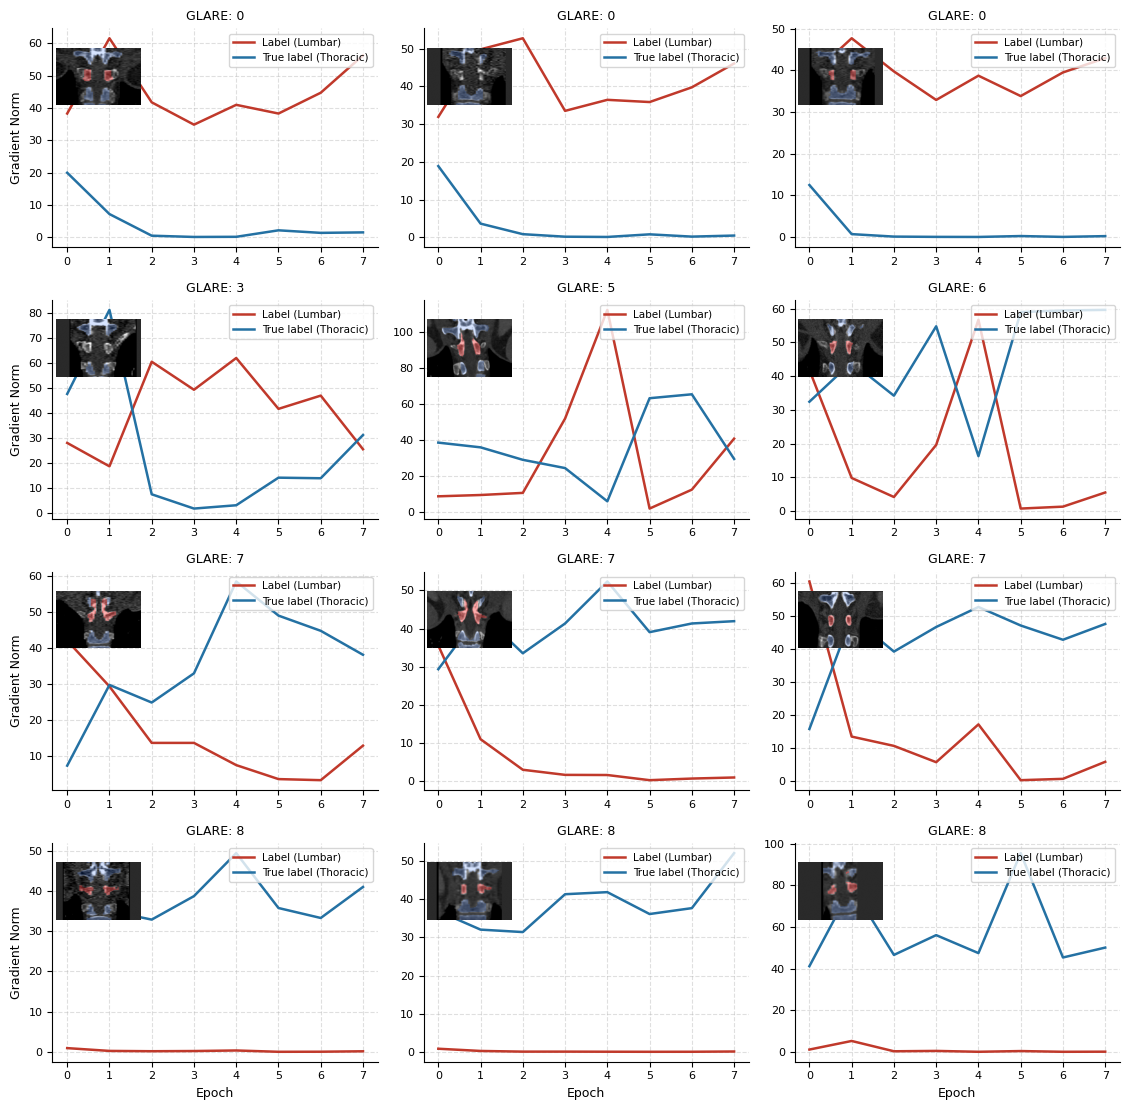

Sample IDs used:
  Detected (score 0–1): ['fxclass0137_dir-sag_sequ-WS30MPR4_vert20', 'ctfu00610_ses-20091111_ce-pv_vert20', 'ID0089_ses-24112010_ce-pv_vert20']
  Borderline (score 3–6): ['ctfu00897_ses-20170303_ce-art_vert20', 'verse601_vert20', 'verse599_dir-iso_vert20']
  Missed (score 7): ['ATL211_dir-sag_vert20', 'verse576_vert20', 'ctfu00509_ses-20060725_ce-pv_vert20']
  Missed (score 8): ['ctfu00544_ses-20140612_ce-pv_vert20', 'ID0260_ses-14092007_ce-pv_vert20', 'ctfu00469_ses-20070904_ce-pv_vert20']


In [18]:
import pickle

GN_PKL = Path("../results/glare/26-09-26_07:42_ep-8_single-gpu/grad_norms_20260926_074211.pkl")
_gn = pickle.load(open(GN_PKL, "rb"))

N_EP         = 8
CLS_NAMES    = {0: "Cervical", 1: "Thoracic", 2: "Lumbar", 3: "Sacral"}
ASSIGNED_CLS = 2   # Lumbar (wrong label for T13)
TRUE_CLS     = 1   # Thoracic (correct class)

def get_epoch_norms(sample_id):
    rows = _gn[_gn["id"] == sample_id].sort_values("epoch")
    return rows[["c0_grad_norm", "c1_grad_norm", "c2_grad_norm", "c3_grad_norm"]].values

# ── Sample selection ───────────────────────────────────────────────────────────
_v = t13_scores[t13_scores["patch_path"].notna()].copy()

NCOLS = 3

grp_low    = _v[_v[INT_SCORE].isin([0, 1])].sort_values(INT_SCORE).head(3).reset_index(drop=True)
grp_mid    = pd.concat([
    _v[_v[INT_SCORE] == s].iloc[[0]]
    for s in [3, 5, 6] if (_v[INT_SCORE] == s).any()
]).head(3).reset_index(drop=True)
grp_high7  = _v[_v[INT_SCORE] == 7].head(3).reset_index(drop=True)
# SR bds category for score-8 row
_anom_m = pd.read_excel(Path("../evaluation/A_CT_ANOMALY_LABELv9.xlsx"))
_anom_m["scan_base"] = _anom_m["fid"]
_anom_m_best = _anom_m.drop_duplicates("scan_base")
_v_cat = _v.copy()
_v_cat["scan_base"] = _v_cat["sample_id"].str.replace(r"_vert\d+$", "", regex=True)
_v_cat = _v_cat.merge(_anom_m_best[["scan_base", "HE Comment"]], on="scan_base", how="left")
grp_high8 = (
    _v_cat[(_v_cat[INT_SCORE] == 8) &
           _v_cat["HE Comment"].apply(lambda c: pd.notna(c) and "bds" in str(c))]
    .head(3).reset_index(drop=True)
)

GROUPS = [
    (grp_low,   "Detected (score 0–1)"),
    (grp_mid,   "Borderline (score 3–6)"),
    (grp_high7, "Missed (score 7)"),
    (grp_high8, "Missed (score 8)"),
]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(GROUPS), NCOLS, figsize=(NCOLS * 3.8, len(GROUPS) * 2.8))

for row_i, (grp, row_label) in enumerate(GROUPS):
    for col_i in range(NCOLS):
        ax = axes[row_i, col_i]

        if col_i >= len(grp):
            ax.axis("off")
            continue

        r         = grp.iloc[col_i]
        sid       = r["sample_id"]
        score_int = int(r[INT_SCORE])

        try:
            norms = get_epoch_norms(sid)
        except Exception as e:
            ax.text(0.5, 0.5, f"No data\n{e}", ha="center", va="center", fontsize=7)
            ax.axis("off")
            continue

        epochs = np.arange(N_EP)

        # Assigned label — red solid
        ax.plot(epochs, norms[:, ASSIGNED_CLS],
                color="#C0392B", linewidth=1.8,
                label=f"Label ({CLS_NAMES[ASSIGNED_CLS]})")

        # True label — green solid
        ax.plot(epochs, norms[:, TRUE_CLS],
                color="#2471A3", linewidth=1.8,
                label=f"True label ({CLS_NAMES[TRUE_CLS]})")


        ax.set_title(f"GLARE: {score_int}", fontsize=9, color="black")
        ax.set_xticks(epochs)
        ax.legend(fontsize=7.5, loc="upper right", labelcolor="black")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(colors="black", labelsize=8)

        if col_i == 0:
            ax.set_ylabel("Gradient Norm", fontsize=9, color="black")
        if row_i == len(GROUPS) - 1:
            ax.set_xlabel("Epoch", fontsize=9, color="black")

        # ── coronal CT inset with segmentation mask ───────────────────────────
        try:
            disk_v_inset = int(r["disk_vert_id"]) if pd.notna(r["disk_vert_id"]) else int(r["vert_id"])
            slc, overlay = load_mid_slice_with_mask(r["patch_path"], disk_v_inset, "coronal")
            inset = ax.inset_axes([0.01, 0.60, 0.26, 0.36])
            inset.imshow(slc, cmap="gray", origin="lower")
            inset.imshow(overlay, origin="lower")
            inset.axis("off")
        except Exception:
            pass

plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/T13_grad_norm_curves_3groups.pdf", bbox_inches="tight")
plt.savefig("/home/student/lisa_ma/figures/T13_grad_norm_curves_3groups.png", dpi=180, bbox_inches="tight")
plt.show()

print("Sample IDs used:")
for grp, label in GROUPS:
    print(f"  {label}: {grp['sample_id'].tolist()}")

category
Rudimentary rib bilateral    20
Super edge case               6
Fused rib                     4
Rib outside FoV               2
SR l/r                        2


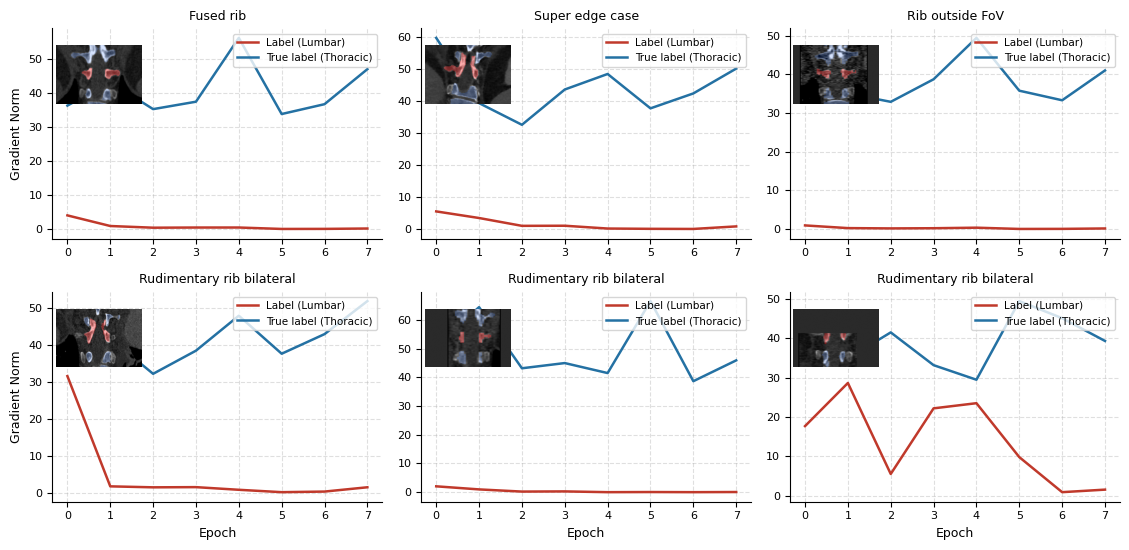

In [19]:
# ── Score 8: difficult/ambiguous cases vs rudimentary rib bilateral (SR bds) ──
_anom2 = pd.read_excel(Path("../evaluation/A_CT_ANOMALY_LABELv9.xlsx"))
_anom2["scan_base"] = _anom2["fid"]
_anom2_best = _anom2.drop_duplicates("scan_base")

missed8 = t13_scores[
    (t13_scores[INT_SCORE] == 8) & t13_scores["patch_path"].notna()
].copy()
missed8["scan_base"] = missed8["sample_id"].str.replace(r"_vert\d+$", "", regex=True)
missed8 = missed8.merge(_anom2_best[["scan_base", "HE Comment"]], on="scan_base", how="left")

def _cat2(c):
    if pd.isna(c): return "Not annotated"
    c = str(c)
    if "SUPER EDGE CASE" in c: return "Super edge case"
    if "Type 4"          in c: return "Fused rib"
    if "abgeschnitten"   in c: return "Rib outside FoV"
    if "bleibt T12"      in c: return "Rib seen, kept as T12"
    if "bds"             in c: return "Rudimentary rib bilateral"
    if "SR"              in c: return "SR l/r"
    return "Not annotated"

missed8["category"] = missed8["HE Comment"].apply(_cat2)
print(missed8["category"].value_counts().to_string())

# ── Row 1: one fused rib, one super edge case, one rib outside FoV ────────────
row1_cats = ["Fused rib", "Super edge case", "Rib outside FoV"]
row1 = []
for cat in row1_cats:
    sub = missed8[missed8["category"] == cat]
    if len(sub):
        row1.append((sub.iloc[0], cat))
    else:
        print(f"WARNING: no sample for '{cat}'")

# ── Row 2: three SR bds samples ───────────────────────────────────────────────
sr_bds = missed8[missed8["category"] == "Rudimentary rib bilateral"].iloc[17:20].reset_index(drop=True)
row2    = [(sr_bds.iloc[i], "Rudimentary rib bilateral") for i in range(len(sr_bds))]

GROUPS2 = [
    (row1, "Ambiguous cases (score 8)"),
    (row2, "Rudimentary rib bilateral — SR bds (score 8)"),
]

fig, axes = plt.subplots(2, 3, figsize=(3 * 3.8, 2 * 2.8))

for row_i, (row_samples, _) in enumerate(GROUPS2):
    for col_i in range(3):
        ax = axes[row_i, col_i]
        if col_i >= len(row_samples):
            ax.axis("off")
            continue

        r, cat_label = row_samples[col_i]
        sid       = r["sample_id"]

        try:
            norms = get_epoch_norms(sid)
        except Exception as e:
            ax.text(0.5, 0.5, f"No data\n{e}", ha="center", va="center", fontsize=7)
            ax.axis("off")
            continue

        epochs = np.arange(N_EP)

        ax.plot(epochs, norms[:, ASSIGNED_CLS], color="#C0392B", linewidth=1.8,
                label=f"Label ({CLS_NAMES[ASSIGNED_CLS]})")
        ax.plot(epochs, norms[:, TRUE_CLS], color="#2471A3", linewidth=1.8,
                label=f"True label ({CLS_NAMES[TRUE_CLS]})")

        ax.set_title(cat_label, fontsize=9, color="black")
        ax.set_xticks(epochs)
        ax.legend(fontsize=7.5, loc="upper right", labelcolor="black")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(colors="black", labelsize=8)

        if col_i == 0:
            ax.set_ylabel("Gradient Norm", fontsize=9, color="black")
        if row_i == 1:
            ax.set_xlabel("Epoch", fontsize=9, color="black")

        try:
            disk_v_inset = int(r["disk_vert_id"]) if pd.notna(r["disk_vert_id"]) else int(r["vert_id"])
            slc, overlay = load_mid_slice_with_mask(r["patch_path"], disk_v_inset, "coronal")
            inset = ax.inset_axes([0.01, 0.60, 0.26, 0.36])
            inset.imshow(slc, cmap="gray", origin="lower")
            inset.imshow(overlay, origin="lower")
            inset.axis("off")
        except Exception:
            pass

plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/T13_score8_comparison.pdf", bbox_inches="tight")
plt.savefig("/home/student/lisa_ma/figures/T13_score8_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

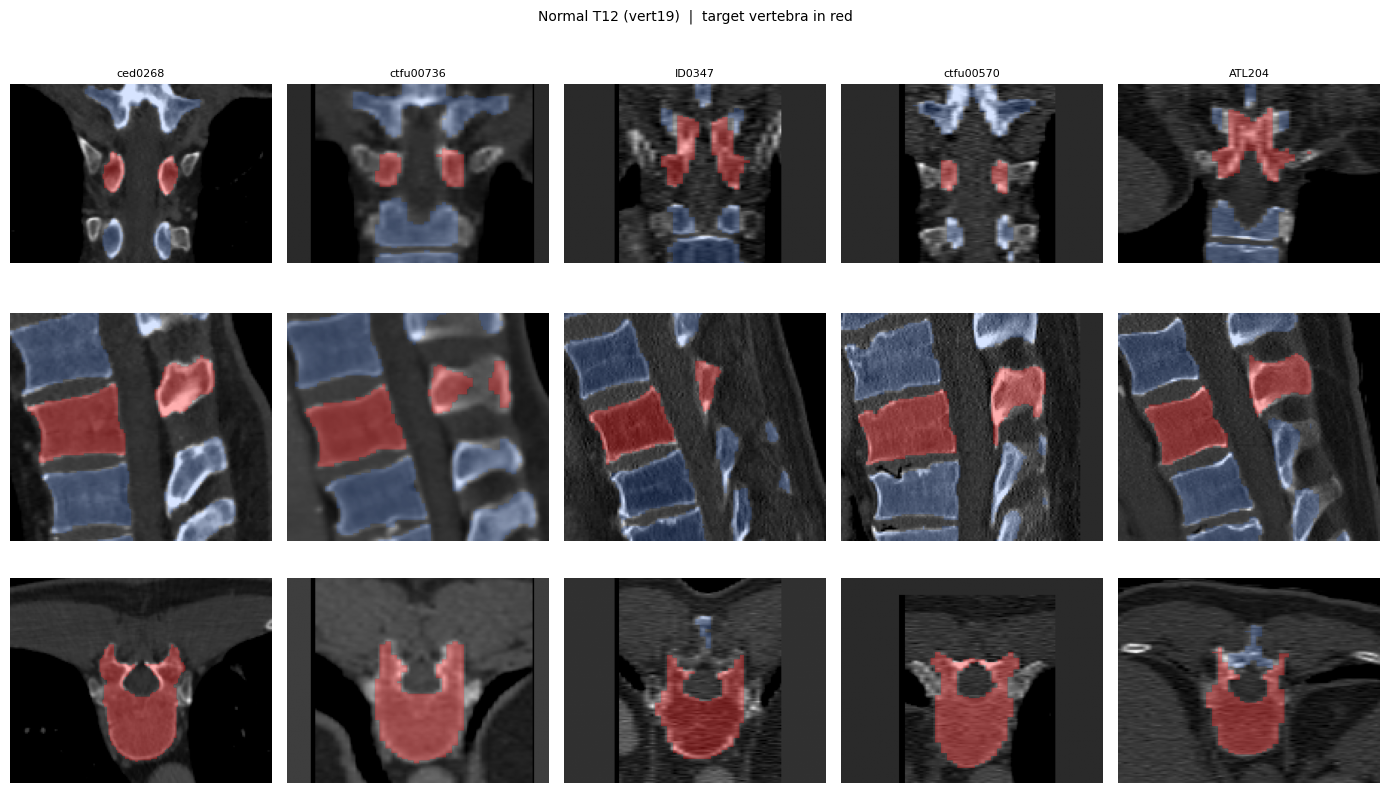

Pool of true T12 samples: 925  |  showing 5


In [20]:
# ── Normal T12 (vert19) — coronal / axial / sagittal reference examples ────────
# True T12 samples: vert19 patches NOT in the GT mislabels list
N_SHOW = 5
VIEWS  = ["coronal", "axial", "sagittal"]

true_t12 = scores[
    scores["sample_id"].str.endswith("_vert19") &
    ~scores["sample_id"].isin(set(pd.read_csv(GT_CSV)["sample_id"]))
].copy()

true_t12["pid"] = true_t12["sample_id"].apply(lambda s: "_".join(s.split("_")[:-1]))
true_t12["patch_path"] = true_t12["pid"].apply(lambda p: get_patch_path(p, 19))
true_t12 = true_t12.dropna(subset=["patch_path"]).reset_index(drop=True)

sample_t12 = true_t12.sample(N_SHOW, random_state=7).reset_index(drop=True)

fig, axes = plt.subplots(len(VIEWS), N_SHOW, figsize=(N_SHOW * 2.8, len(VIEWS) * 2.8))

for row, view in enumerate(VIEWS):
    for col, (_, r) in enumerate(sample_t12.iterrows()):
        ax = axes[row, col]
        img_slc, overlay = load_mid_slice_with_mask(r["patch_path"], 19, view)
        ax.imshow(img_slc, cmap="gray", origin="lower")
        ax.imshow(overlay, origin="lower")
        if row == 0:
            ax.set_title(r["pid"].split("_")[0], fontsize=8)
        if col == 0:
            ax.set_ylabel(view, fontsize=8, rotation=0, labelpad=42, va="center")
        ax.axis("off")

fig.suptitle("Normal T12 (vert19)  |  target vertebra in red", fontsize=10)
plt.tight_layout()
plt.show()

print(f"Pool of true T12 samples: {len(true_t12)}  |  showing {N_SHOW}")

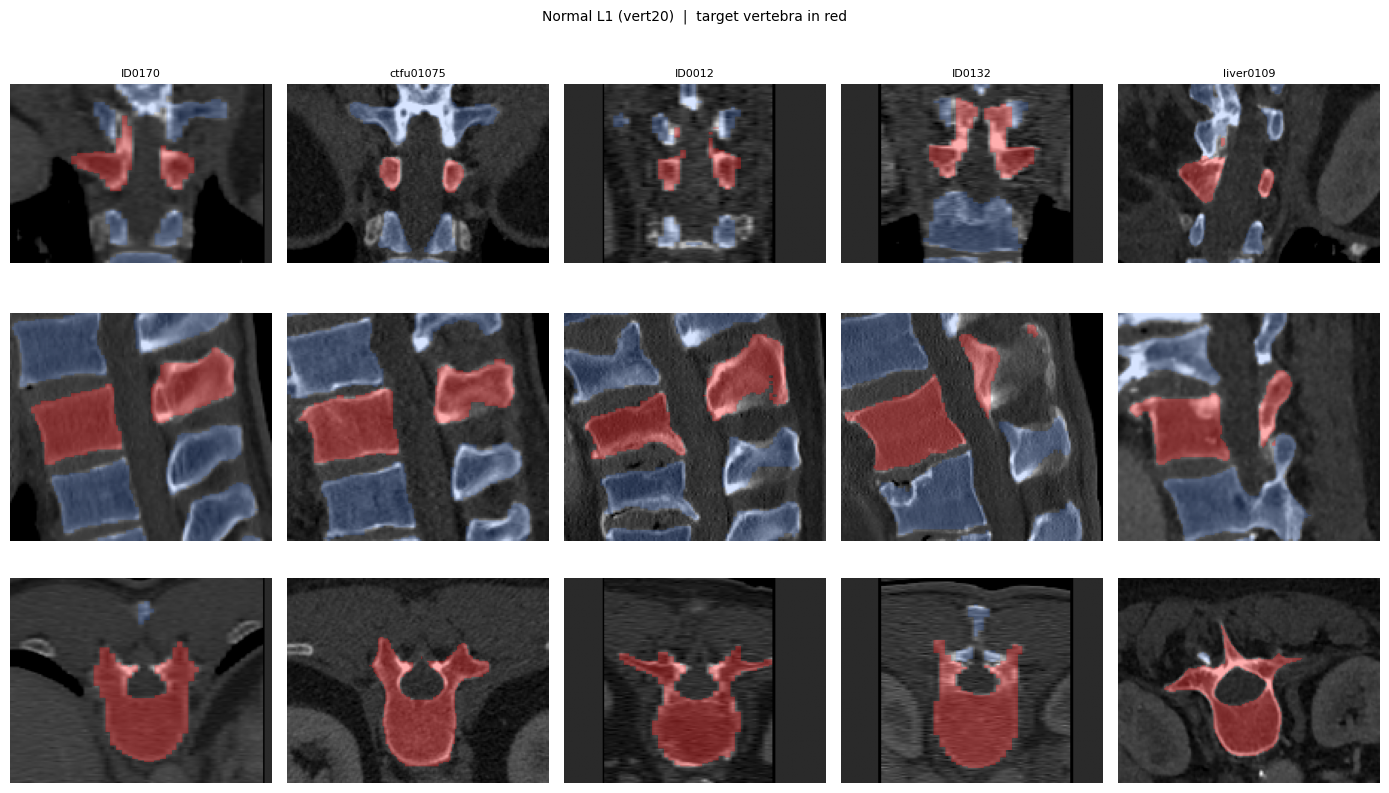

Pool of true L1 samples: 867  |  showing 5


In [21]:
# ── Normal L1 (vert20) — coronal / axial / sagittal reference examples ─────────
# True L1 samples: vert20 patches NOT in the GT mislabels list
N_SHOW = 5
VIEWS  = ["coronal", "axial", "sagittal"]

true_l1 = scores[
    scores["sample_id"].str.endswith("_vert20") &
    ~scores["sample_id"].isin(set(pd.read_csv(GT_CSV)["sample_id"]))
].copy()

true_l1["pid"] = true_l1["sample_id"].apply(lambda s: "_".join(s.split("_")[:-1]))
true_l1["patch_path"] = true_l1["pid"].apply(lambda p: get_patch_path(p, 20))
true_l1 = true_l1.dropna(subset=["patch_path"]).reset_index(drop=True)

sample_l1 = true_l1.sample(N_SHOW, random_state=7).reset_index(drop=True)

fig, axes = plt.subplots(len(VIEWS), N_SHOW, figsize=(N_SHOW * 2.8, len(VIEWS) * 2.8))

for row, view in enumerate(VIEWS):
    for col, (_, r) in enumerate(sample_l1.iterrows()):
        ax = axes[row, col]
        img_slc, overlay = load_mid_slice_with_mask(r["patch_path"], 20, view)
        ax.imshow(img_slc, cmap="gray", origin="lower")
        ax.imshow(overlay, origin="lower")
        if row == 0:
            ax.set_title(r["pid"].split("_")[0], fontsize=8)
        if col == 0:
            ax.set_ylabel(view, fontsize=8, rotation=0, labelpad=42, va="center")
        ax.axis("off")

fig.suptitle("Normal L1 (vert20)  |  target vertebra in red", fontsize=10)
plt.tight_layout()
plt.show()

print(f"Pool of true L1 samples: {len(true_l1)}  |  showing {N_SHOW}")

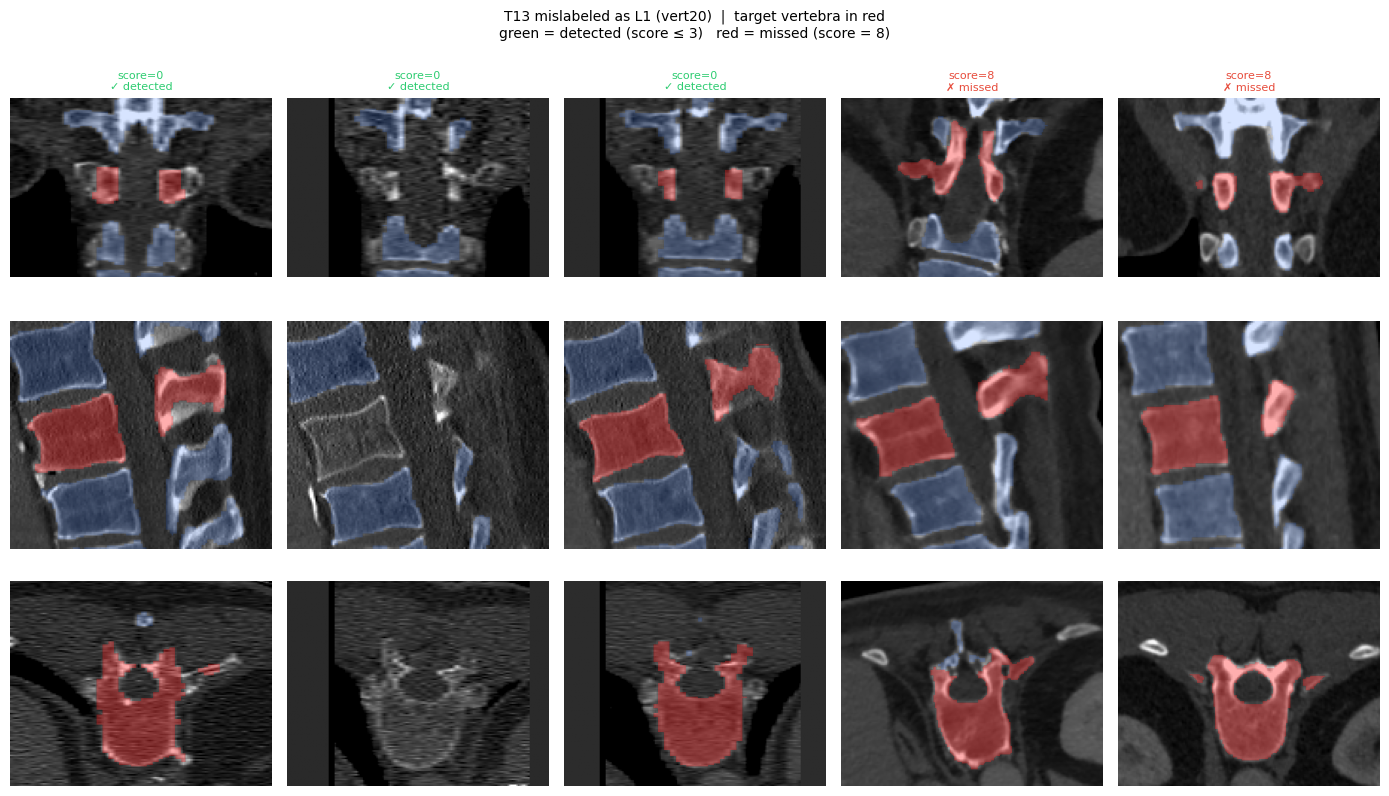

In [22]:
# ── T13 (vert20 mislabeled as L1) — coronal / axial / sagittal, detected vs missed
# Mix: 2–3 detected (score ≤ 3) + 2–3 missed (score = 8)
VIEWS    = ["coronal", "axial", "sagittal"]
N_DET    = 3
N_MISS   = 2

det  = (t13_scores[(t13_scores[INT_SCORE] <= 3) & t13_scores["patch_path"].notna()]
        .sort_values(INT_SCORE).head(N_DET).reset_index(drop=True))
miss = (t13_scores[(t13_scores[INT_SCORE] == 8) & t13_scores["patch_path"].notna()]
        .head(N_MISS).reset_index(drop=True))

samples = pd.concat([det, miss], ignore_index=True)

fig, axes = plt.subplots(len(VIEWS), len(samples), figsize=(len(samples) * 2.8, len(VIEWS) * 2.8))

for row, view in enumerate(VIEWS):
    for col, (_, r) in enumerate(samples.iterrows()):
        ax = axes[row, col]
        disk_v = int(r["disk_vert_id"]) if pd.notna(r["disk_vert_id"]) else int(r["vert_id"])
        img_slc, overlay = load_mid_slice_with_mask(r["patch_path"], disk_v, view)
        ax.imshow(img_slc, cmap="gray", origin="lower")
        ax.imshow(overlay, origin="lower")
        if row == 0:
            score_int = int(r[INT_SCORE])
            detected  = score_int <= 3
            colour    = "#2ecc71" if detected else "#e74c3c"
            label     = f"score={score_int}\n{'✓ detected' if detected else '✗ missed'}"
            ax.set_title(label, fontsize=8, color=colour)
        if col == 0:
            ax.set_ylabel(view, fontsize=8, rotation=0, labelpad=42, va="center")
        ax.axis("off")

fig.suptitle("T13 mislabeled as L1 (vert20)  |  target vertebra in red\n"
             "green = detected (score ≤ 3)   red = missed (score = 8)", fontsize=10)
plt.tight_layout()
plt.show()